# Homework 4 - Neural decoding

### Preface
For plotting results of multiple runs of a simulated BCI, we will use "violin" plots in this homework. They are easy do with the `seaborn` and `pandas` packages. So if all you've installed sofar are `matplotlib` and `numpy`, please install these two more.

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


### The data
The data for this lab are courtesy of the lab of the late Krishna Shenoy. These are spikes recorded from the dorsal premotor cortex (PMd) of a non-human primate engaged in a center out reaching task with an instructed delay carried out on a touch screen in front of the subject. The sample code below loads the spiking data and task metadata for each trial. For this homework assignment, we will be decoding neural activity generated in PMd during the delay period of the task (when the target is being displayed but the animal has not yet been instructed to initiate movement). We will use the timestamps associated with the start of the trial with a target onset (`time_touch_held`) and the end of the planning period for that trial, which we will approximate using the time when the go cue is shown (`time_go_cue`). In addition, in order to train the decoder and evaluate decoding performance, we need the identity of the target for each trial (`trial_reach_target`). Some other metadata are also in the file and are extracted below.

In [19]:
with open('homework4_spikes.npz', 'rb') as loadfile:
    spike_times = np.load(loadfile, allow_pickle=True)['spike_times']

with open('homework4_metadata.npy', 'rb') as loadfile:
    metadata = np.load(loadfile)
    # Note that all of these are vectors with dimensions Kx1, where K is the number of trials
    time_touch_held = metadata['time_touch_held'] # target onset times for each trial
    time_go_cue = metadata['time_go_cue'] # go cue time for each trial
    time_target_acquired = metadata['time_target_acquired'] # time the target was touched
    trial_reach_target = metadata['trial_reach_target'] # index of reach target for each trial (0 through 7)
        # note that I've "fixed" the reach targets to be 0-7 rather than 1-8
    target_locations = metadata['target_locations'] # x,y location of each target
    target_angles = metadata['target_angles'] # angle of each target


In this dataset, to prevent anticipatory movements, the animal was randomly given trials with different delay durations! That will add a bit of complexity to how we think about implementing the decoder.

In [20]:
# Verify that there are in fact two different plan period durations
np.unique(time_go_cue - time_touch_held)

array([ 755, 1005])

We'll start by providing a simple function that extracts the number of spikes from each neuron in a period of time relative to the beginning of each trial. We'll define it with two parameters - the duration of the window in which to count spikes, and an offset from the trial beginning. When called, this function will return a matrix - each column represents the activity of the neurosn for a single trial, since there are 1127 trials and 190 neurons, the matrix is 190 x 1127.

In [21]:
def extract_plan_spikes(window_length=None,
                        start_offset=None):
    # Return a matrix of spike counts in the plan window.
    # - The default plan window is defined as the time between
    #   time_touch_held and time_go_cue for each trial. NOTE:
    #   not all trials have the same duration!!!
    # - If a "window_length" is specified, return the number
    #   of spikes in the window of that duration. Return -1
    #   if the available plan period is too short for the window
    #   (for example, window_length=1000 but the trial plan
    #   period is just 755 ms).
    # - If a "start_offset" is specified, return the number of
    #   spikes in the window defined as starting "start_offset"
    #   ms after the time_touch_held. (Use either time_go_cue
    #   or the optional window_length to determine window end.)
    #   If start_offset is so large that it extends past the
    #   time_go_cue, return -1.

    if start_offset:
        trial_starts = time_touch_held + start_offset
    else:
        trial_starts = time_touch_held

    plan_spikes = [] # We'll make a list of the spike counts for each trial
    for tx, trialSpikes in enumerate(spike_times): # spike times is a list of size 190 (# of neurons)
        if window_length: # if it wasn't None
            trial_end = trial_starts[tx] + window_length
        else:
            trial_end = time_go_cue[tx]

        if (trial_end < trial_starts[tx]) or (trial_end > time_go_cue[tx]): # Use a -1 for each neuron if there's an error
                plan_spikes.append(-np.ones(len(trialSpikes)))
        else:
            plan_spikes.append(
                np.array([np.sum((st > trial_starts[tx]) &
                        (st < trial_end)) for st in trialSpikes]))
    return np.array(plan_spikes).T # will be 190 x 1127 (number of neurons by number of trials)

In [22]:
plan_spikes = extract_plan_spikes()
print(plan_spikes.shape)

(190, 1127)


# Problem 1 - How does the window (duration and relative start time) used to decode the plan activity affect decoding performance?
We'll want to answer two subquestions for Problem 1. The first sub-question is "How does the duration of the window we use to decode affect decoder performance?" Naively, we expect that a longer duration which will yield more spikes, should give better performance, but that comes with a tradeoff of increased latency for decoding. So we'll plot the tradeoff to understand it. The second question has to do with exactly what spikes we should use for decoding. Information takes time to propagate from the retina through visual processing to frontal motor areas. Thus, the time when actual planning begins in the brain is sometime after the trial start. We will use a fixed duration window for decoding that we slide forward from the trial start to find when the optimal decoder window should begin.

We'll begin by implementing a Poisson Maximum Log Likelihood decoder. The first step is to pick a set of trials for training, keeping track of the remaining ones to use for testing. For the training trials, we want the same number for each possible reach target. In addition, to keep things simplest, lets start with just the 755 ms instructed delay trials. Before we can randomly pick trials for training, let's make a list of the trial indices for each target.

### (You'll come back to this cell later!)

In [23]:
# select the 755 ms plan period trials for testing
short_trials = (time_go_cue - time_touch_held) == 755 # boolean array

target_trials = []
for c in range(8): # reach targets go from 0 to 7
    target_trials.append(np.argwhere(short_trials & (trial_reach_target==c)).squeeze())


Next, we'll randomly pick 25 training trials from each target's list, keeping the remaining trials for testing.

### (You'll come back to this cell later!)

In [24]:
training_trials = [] # will be 8 lists of trial indices (one list per direction)
test_trials = [] # all the leftovers
for c in range(8): # reach targets go from 0 to 7
    # randomly select 25 training trials per direction
    random_training_trials = np.random.choice(target_trials[c], 25, replace=False) # numpy helper that picks a random subset of samples
    training_trials.append(random_training_trials)
    remaining_test_trials = np.setdiff1d(target_trials[c], random_training_trials) # which ones are left?

    test_trials.extend(remaining_test_trials) # we use "extend" to make one long list of test trials, which will include all targets


The key parameter(s) for Poisson Maxmimum Log Likelihood decoding is the mean number of spike counts. Specifically, for each neuron, we need the mean number of spike counts across the training trials for each direction (190 neurons x 8 trials).

The very-new-to-python coder might do it this way:

In [25]:
# Calculate the mean spike counts per neuron for each target
num_neurons = plan_spikes.shape[0]
mean_spike_counts = np.zeros((num_neurons, 8))
for c in range(8):
    for neuron in range(num_neurons):
        # Calculate the mean as sum divided by 25
        mean_spike_counts[neuron,c] = 0
        for trial_index in training_trials[c]:
            mean_spike_counts[neuron,c] += plan_spikes[neuron, trial_index]
        mean_spike_counts[neuron,c] = mean_spike_counts[neuron,c] / 25

But please don't do that! Do it the easy way, with the numpy indexing and functions that make your life easier!

In [26]:
# Calculate the mean spike counts per neuron for each target
num_neurons = plan_spikes.shape[0]
mean_spike_counts = np.zeros((num_neurons, 8))
for c in range(8):
    mean_spike_counts[:,c] = np.mean(plan_spikes[:, training_trials[c]], axis=1)


The last line is a critical bit of `numpy` coding. First, recall that `plan_spikes` is all our spike counts for all our neurons for all our trials. It's a matrix of size 190 (number of neurons) x 1127 (number of trials). When we do `plan_spikes[:,training_trials[c]]`, we're saying give me all the rows (the first `:`) for the columns with indexs in the list `training_trials[c]`. So that indexed array will be of size 190 (number of neurons) x 25 (number of training trials). Second, once we have this array, we want to take the mean for each neuron across the training trials. The function `np.mean()` allows you to specify an `axis` to take the mean along. In this case, we want to take the mean along the second axis (Python counts from 0) - over the trials.

_In Problem 1, we'll be choosing different time windows to count the `plan_spikes` matrix with. In Problem 2, you'll need to choose subsets of neurons instead. This will require indexing (BUT NOT CALCULATING THE MEAN) along the first axis to pull out the data from a subset of the neurons._



Next, let's write a function to calculate the log probability of a set of Poisson neurons. We can't use `lambda` as the name for our parameter because its a reserved term in python, so we'll use `mu`. In this function, `mu` will be a vector of Nx1, where N is the number of neurons. We also will take the observations (spike counts), which for efficiency we'll calculate for many trials simultaneously. So `X` will be Nxd, where d is the number of trials. _(Note that for Problem 2, N will be less than 190, but the actual dimension of N is not specified in the function. Everything works as long as `mu` and `X` have the same first dimension.)_

Two last little  details. First, we'll ignore the factorial term, since it doesn't depend on `mu`, so it's the same for all potential targets. Second, if `mu` is too small, that can cause trouble, so we need to replace too-small `mu`'s with a minimum value.

In [27]:
def multivariate_poisson_logpdf(mu, X, mean_eps=0.01):
    # assume mu is (N,) and x is (N,d)
    mu2 = mu
    mu2[np.argwhere(mu < mean_eps)] = mean_eps
    return np.sum(X.T * np.log(mu2) - mu2, axis=1)

We have now calculated our Poisson parameters, and have a function to calculate the log likelihood of each target for each trial. So let's do it!

And let's do it efficiently, for all the test trials and all the targets at once!!! We were smart when we wrote our `multivariate_poisson_logpdf` function, so we can call it once for each target with all the test trials. The final product will be an array that's of size number_of_test_trials x number_of_targets.

In [28]:
# Calculate probability for each target and each test trial
poisson_likelihood = np.zeros((len(test_trials), 8))
for c in range(8):
    m = mean_spike_counts[:,c]
    poisson_likelihood[:,c] = \
        multivariate_poisson_logpdf(m, plan_spikes[:, test_trials])


The final step is to find, for each trial, which target has the largest log likelihood. Again, we're going to use numpy `axis` selection to be efficient here. In this case, we're using the `argmax` function, which tells which index of a vector has the largest value. By choosing `axis=1`, we're asking it to work on the second dimension, the number-of-targets dimension. So we'll get out a vector of indices, where each trial row in our log likelihood decoder matrix, we have the index to the column (target) which had the largest likelihod (for that trial).

Finally, we can compare it to the identity of the correct targets, and calculate a fraction correct. We'll use one more coding trick here. `True` is numerically equal to 1, and `False` is 0, so if we take a mean of a boolean vector (`correct_targets==decoded_targets`), we'll get the fraction of 1's, or the fraction correct.

In [29]:
correct_targets = trial_reach_target[test_trials] # correct target for each trial
decoded_targets = np.argmax(poisson_likelihood,axis=1) # decoded target is just the max index
print('Poisson Correct: ', np.mean(correct_targets==decoded_targets))
print('({} test trials)'.format(len(test_trials)))

Poisson Correct:  0.9230769230769231
(364 test trials)


# Problem 1A (10 pts)

Go back up to the random trial selection cell above and run down to this "Fraction Correct" cell and run it a few times. What range of values do you observe?

Modify the code to use the first 750 ms of the plan window for both long and short trial types, by:

+ changing the line `target_trials = np.argwhere(short_trials & (trial_reach_target==c)).squeeze()` to be simply `target_trials = np.argwhere((trial_reach_target==c)).squeeze()` (without the “short trials”), and
+ changing the line `plan_spikes = extract_plan_spikes()` to `plan_spikes = extract_plan_spikes(window_length=750)` (to use the first 750 ms of plan activity for the spike counts for all trials).

Now we will have the same number of training trials but many more test trials. Run through a few more times of randomized training trial choice. Does this change the variability in the fraction correct?

In [35]:
plan_spikes = extract_plan_spikes(window_length=750)

# select the 755 ms plan period trials for testing
short_trials = (time_go_cue - time_touch_held) == 755 # boolean array

target_trials = []
for c in range(8): # reach targets go from 0 to 7
    target_trials.append(np.argwhere((trial_reach_target==c)).squeeze())

training_trials = [] # will be 8 lists of trial indices (one list per direction)
test_trials = [] # all the leftovers
for c in range(8): # reach targets go from 0 to 7
    # randomly select 25 training trials per direction
    random_training_trials = np.random.choice(target_trials[c], 25, replace=False) # numpy helper that picks a random subset of samples
    training_trials.append(random_training_trials)
    remaining_test_trials = np.setdiff1d(target_trials[c], random_training_trials) # which ones are left?
    test_trials.extend(remaining_test_trials) # we use "extend" to make one long list of test trials, which will include all targets

# Calculate the mean spike counts per neuron for each target
num_neurons = plan_spikes.shape[0]
mean_spike_counts = np.zeros((num_neurons, 8))
for c in range(8):
    mean_spike_counts[:,c] = np.mean(plan_spikes[:, training_trials[c]], axis=1)

# Calculate probability for each target and each test trial
poisson_likelihood = np.zeros((len(test_trials), 8))
for c in range(8):
    m = mean_spike_counts[:,c]
    poisson_likelihood[:,c] = \
        multivariate_poisson_logpdf(m, plan_spikes[:, test_trials])


correct_targets = trial_reach_target[test_trials] # correct target for each trial
decoded_targets = np.argmax(poisson_likelihood,axis=1) # decoded target is just the max index
print('Poisson Correct: ', np.mean(correct_targets==decoded_targets))
print('({} test trials)'.format(len(test_trials)))

Poisson Correct:  0.9309600862998921
(927 test trials)


Running the random trial selection cells gave a range of values between .926-.942. But after taking out short trials, the values were about .918-.947. Although there is some variability, it is relatively small.

# Problem 1B (20 pts) - How does the duration of the decoding window affect performance?

Calculating performance for only one selection of training and test trials will not adequately reflect the true average performance. The right thing to do is to test accross many possible selections of training and test trials. In the next cell, there is skeleton code that loops over different sizes of plan windows (outer `for` loop) and repetitions of random training/test trial selection (inner `for` loop). You should be able to fill in the code by copying and pasting (but make sure your indentations are correct! - the code blocks you'll paste are now running repeatedly inside these loops). If everything works, you should be able to run the next cell and generate a beautiful figure like the one shown.

In [30]:
num_neurons = 190

target_trials = []
for c in range(8):
    target_trials.append(np.argwhere(trial_reach_target==c).squeeze())

decode_perf = [] # this will be a list of lists - outer list is different plan window sizes, inner list is statistical repititions
for plan_window in np.arange(50,800,50): # (this goes to 750!!!)
    plan_spikes = extract_plan_spikes(window_length=plan_window)
    decode_perf.append([])

    # Randomly choose training and test data 25 times
    for i in range(50):

        training_trials = [] # will be 8 lists of trials
        test_trials = [] # all the leftovers
        #### Fill in the random selection of training and test trials here
        for c in range(8):
          random_training_trials = np.random.choice(target_trials[c], 25, replace=False)
          training_trials.append(random_training_trials)
          remaining = np.setdiff1d(target_trials[c], random_training_trials)
          test_trials.extend(remaining)

        mean_spike_counts = np.zeros((num_neurons, 8))
        #### Fill in the calculation of the mean_spike_counts for each target here
        for c in range(8):
          mean_spike_counts[:,c] = np.mean(plan_spikes[:, training_trials[c]], axis=1)

        poisson_likelihood = np.zeros((len(test_trials), 8))
        #### Fill in the calculation of the Poisson log likelihoods here
        for c in range(8):
          m = mean_spike_counts[:,c]
          poisson_likelihood[:,c] = multivariate_poisson_logpdf(m, plan_spikes[:, test_trials])

        correct_targets = trial_reach_target[test_trials] # correct target for each trial
        decoded_targets = np.argmax(poisson_likelihood,axis=1) # decoded target is just the max index
        decode_perf[-1].append(np.mean(correct_targets==decoded_targets))

decode_perf = np.array(decode_perf) # convert to a numpy array



[Text(0.5, 0, 'Plan Window Duration in ms'), Text(0, 0.5, 'Decode Accuracy')]

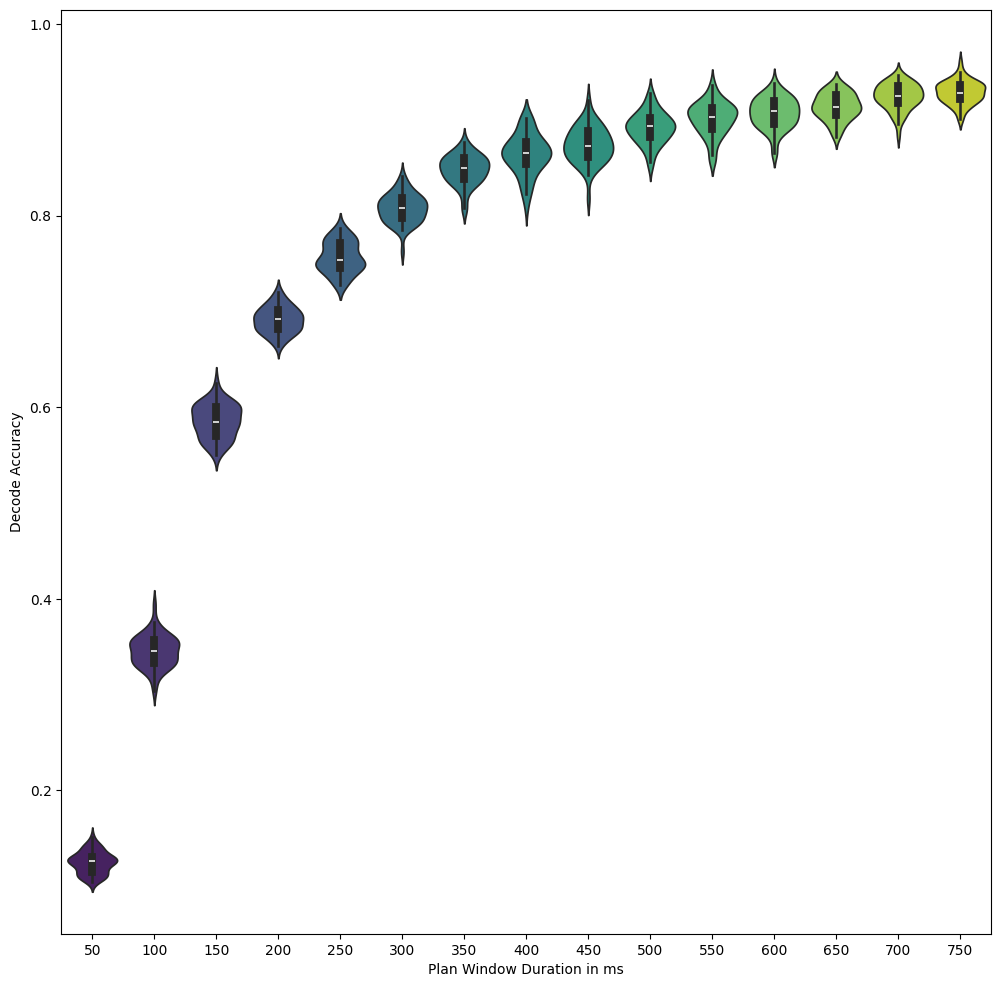

In [31]:
fig = plt.figure(figsize=(12,12))
ax = sns.violinplot(data=pd.DataFrame(decode_perf.T,
                              columns=np.arange(50,800,50)),
                              palette="viridis")
ax.set(xlabel='Plan Window Duration in ms', ylabel='Decode Accuracy')


This figure shows us that as plan window duration increases our decoder accuracy also increases. This occurs because the more spikes within the plan window we have and the larger the data set, the greater accuracy level we have.

# Problem 1C (20 pts) - Where should the plan window begin?

As discussed in class, the time when the brain actually begins planning is some moments after when the target appears. You will use decoding to identify this moment. To be able to see a big difference, use a small window size, and make sure that the sum of the `start_offset` and the `window_length` parameters is less than 750 (to make sure all windows are valid both for long and short trials). You can use a very similar loop to the one above, except now, you make the outer loop loop over the `start_offset` parameter:

```
decode_perf = [] # this will be a list of lists - outer list is different plan window starts, inner list is statistical repititions
for start_offset in np.arange(0,525,25): # (with a window length of 250, this will go to 750!!!)
    plan_spikes = extract_plan_spikes(window_length=250, start_offset=start_offset)

    ... # other code you'll potentially need to modify???

```

Plot the results - based on decode performance, when do you think the window of neural planning actually starts? (If you want, you can modify the `np.arange` line in the code to give higher temporal resolution, or modify the window_length.)

In [32]:

decode_perf = [] # this will be a list of lists - outer list is different plan window starts, inner list is statistical repititions
for start_offset in np.arange(0,600,25): #Stays under 750 with window length of 150
    plan_spikes = extract_plan_spikes(window_length=150, start_offset=start_offset) #Much sharper timing but balanced with relatively less noise still
    decode_perf.append([])

    for i in range(50):
        training_trials = [] # will be 8 lists of trials
        test_trials = [] # all the leftovers
        #### Fill in the random selection of training and test trials here
        for c in range(8):
          random_training_trials = np.random.choice(target_trials[c], 25, replace=False)
          training_trials.append(random_training_trials)
          remaining = np.setdiff1d(target_trials[c], random_training_trials)
          test_trials.extend(remaining)

        mean_spike_counts = np.zeros((num_neurons, 8))
        #### Fill in the calculation of the mean_spike_counts for each target here
        for c in range(8):
          mean_spike_counts[:,c] = np.mean(plan_spikes[:, training_trials[c]], axis=1)

        poisson_likelihood = np.zeros((len(test_trials), 8))
        #### Fill in the calculation of the Poisson log likelihoods here
        for c in range(8):
          m = mean_spike_counts[:,c]
          poisson_likelihood[:,c] = multivariate_poisson_logpdf(m, plan_spikes[:, test_trials])

        correct_targets = trial_reach_target[test_trials] # correct target for each trial
        decoded_targets = np.argmax(poisson_likelihood,axis=1) # decoded target is just the max index
        decode_perf[-1].append(np.mean(correct_targets==decoded_targets))

decode_perf = np.array(decode_perf) # convert to a numpy array



[Text(0.5, 0, 'Window start after target onset in ms'),
 Text(0, 0.5, 'Decode Accuracy')]

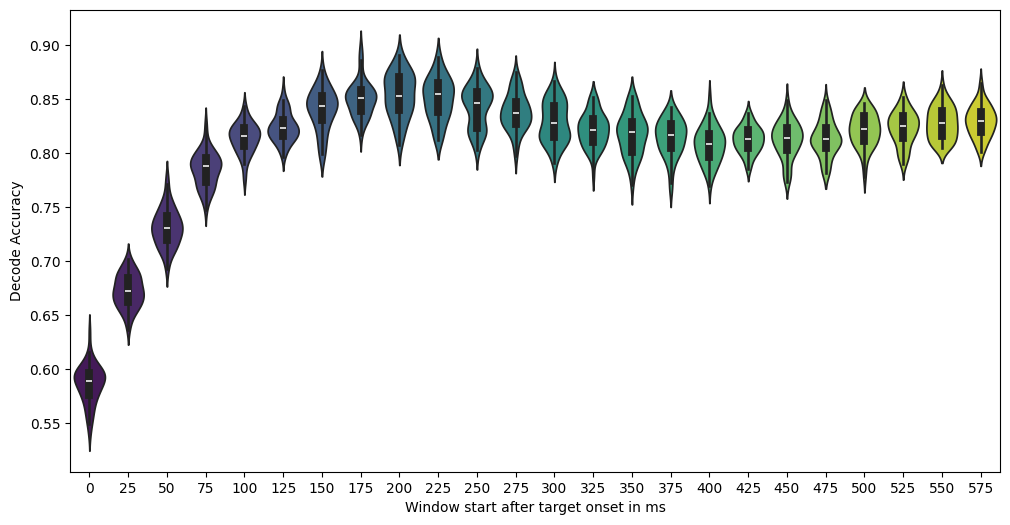

In [33]:
fig = plt.figure(figsize=(12,6))
ax = sns.violinplot(data=pd.DataFrame(decode_perf.T,
                              columns=np.arange(0,600,25)),
                              palette="viridis")
ax.set(xlabel='Window start after target onset in ms', ylabel='Decode Accuracy')

I used a 150 ms window so that each window covered a smaller period of time to make the start of planning activity easier to see. Accuracy goes from about ~58% when the window starts at target onset to closer to 83% when starting at 100 ms. Based on this and the steep rise that occurs before 100 ms after target onset, I think that neural planning activity starts around 50-100 ms after target onset. This would make sense since it takes time for visual information to travel from the eye to the visual processing areas to the premotor cortex. After planning has commenced, the information stays stable, which is in agreement with what happens later on in the graph as the accuracy levels plateau.

# Problem 2A (30 pts) - How does the number of neurons affect performance?

Now modify the code from 1B to randomly select neural ensembles in addition to training and test trials. You should use a 250 ms plan window with a 100 ms offset. Evaluate average decoding performance as a function of the number of neurons used by the decoder. Specifically, repeatedly (at least 25 times) randomly sample groups of neurons of size 30, 60, 90, 120, and 150, and calculate average decode performance. About how many neurons do you need for good performance?

Hints on code to modify. If the indices of your random neurons are in neuron_idx, you need to change the code that calculates the mean spike counts:

```
    num_neurons = len(neuron_idx)
    mean_spike_counts = np.zeros((num_neurons, 8))
    for c in range(8):
        mean_spike_counts[:,c] = np.mean(plan_spikes[neuron_idx][:,training_trials[c]], axis=1)
```

Furthemore, you’ll need to change the code that calculates the likelihood:
```
    poisson_likelihood[:,c] =
        multivariate_poisson_logpdf(m, plan_spikes[neuron_idx][:.test_trials])
```

To get random indices of neurons, you can use the `numpy.random.choice` function in a similar way to how the train trials are selected.
```
    neuron_idx = np.random.choice(range(190), NUMBER_OF_NEURONS, replace=False)
```

In particular, the “replace=False” instruction is important. Without it, the default is to potentially give multiple copies of the same value. 190 here is the total number of values you want to randomly sample from - there are 190 neurons in the dataset. (And `NUMBER_OF_NEURONS` would be replaced with the name of the variable that your outer loop is generating.)


In [44]:
plan_spikes = extract_plan_spikes(window_length=250, start_offset=100)
decode_perfofneurons = []
groupsizes = np.array([30,60,90,120,150])

for neuronused in groupsizes:
  ensembleperf = []

  for i in range(50):

 #select random 25 sample groups to use as training_trials
    training_trials = []
    test_trials = []

    for c in range(8):
        random_training_trials = np.random.choice(target_trials[c],25, replace=False)
        training_trials.append(random_training_trials)
        remaining = np.setdiff1d(target_trials[c], random_training_trials)
        test_trials.extend(remaining)

    neuron_idx = np.random.choice(range(190), neuronused, replace=False)

    #find average spike count for each selected neuron
    num_selectedneurons = len(neuron_idx)
    mean_spike_counts = np.zeros((num_selectedneurons, 8))
    for c in range(8):
        mean_spike_counts[:,c] = np.mean(plan_spikes[neuron_idx][:,training_trials[c]], axis=1)

    #compare test trial matches to targets using poisson likelihood
    poisson_likelihood = np.zeros((len(test_trials), 8))
    for c in range(8):
        m = mean_spike_counts[:,c]
        poisson_likelihood[:,c] = multivariate_poisson_logpdf(m, plan_spikes[neuron_idx][:,test_trials])

    correct_targets = trial_reach_target[test_trials] # correct target for each trial
    decoded_targets = np.argmax(poisson_likelihood,axis=1) # decoded target is just the max index
    ensembleperf.append(np.mean(correct_targets==decoded_targets))
  decode_perfofneurons.append(ensembleperf)
decode_perfofneurons = np.array(decode_perfofneurons) # convert to a numpy array


In [46]:
fig = plt.figure(figsize=(12,6))
ax = sns.violinplot(data=pd.DataFrame(decode_perf.T,
                              columns=groupsizes),
                              palette="viridis")
ax.set(xlabel='Neural Ensemble', ylabel='Decode Accuracy')

ValueError: Shape of passed values is (50, 24), indices imply (50, 5)

<Figure size 1200x600 with 0 Axes>

Average decode accuracy is around .56 for 30 neurons, .75 for 60, .80 for 90, .85 for 120, and .88 for 150. Improvements in accuracy start tapering off at about 90 neurons, so choosing any neuron selection above/around 90 seems like a good enough estimate.

# Problem 2B (20 pts) - How does firing rate change performance?

Using the `mean_spike_counts` calculated for the whole ensemble, find the 30 neurons with the average highest firing rates (averaged over all directions), and the 30 neurons with the lowest average firing rates. The function `numpy.argsort` will help you here by giving you sorted indices - you can pick the first 30 outputs or the last 30. How does the decode performance of these two cherry picked ensembles compare with average performance from randomly selected neurons?

[Text(0.5, 0, 'Number of selected neurons'), Text(0, 0.5, 'Decode Accuracy')]

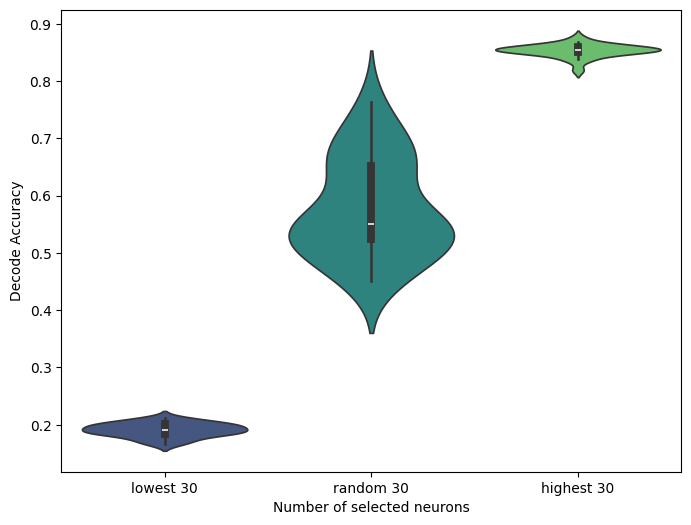

In [54]:
num_neurons = 190
plan_spikes = extract_plan_spikes(window_length=250, start_offset=100)

target_trials = []
for c in range(8):
    target_trials.append(np.argwhere(trial_reach_target==c).squeeze())

mean_spike_counts = np.zeros((num_neurons, 8))
for c in range(8):
    mean_spike_counts[:,c] = np.mean(plan_spikes[:, training_trials[c]], axis=1)
firing_rates = mean_spike_counts.mean(axis=1)

sortidx = np.argsort(firing_rates)
lowest30 = sortidx[:30]
highest30 = sortidx[-30:]

groups = ['lowest 30', 'random 30', 'highest 30']
decode_perf = []
for group in groups:
    decode_perf.append([])

    for i in range(25):
        if group == 'lowest 30':
          neuron_idx = lowest30
        elif group == 'random 30':
          neuron_idx = np.random.choice(range(190), 30, replace=False)
        elif group == 'highest 30':
          neuron_idx = highest30
        num_neurons = len(neuron_idx)

        training_trials = [] # will be 8 lists of trials
        test_trials = [] # all the leftovers
        for c in range(8):
          random_training_trials = np.random.choice(target_trials[c], 25, replace=False)
          training_trials.append(random_training_trials)
          remaining = np.setdiff1d(target_trials[c], random_training_trials)
          test_trials.extend(remaining)

        mean_spike_counts = np.zeros((num_neurons, 8))
        for c in range(8):
          mean_spike_counts[:,c] = np.mean(plan_spikes[neuron_idx][:, training_trials[c]], axis=1)

        poisson_likelihood = np.zeros((len(test_trials), 8))
        for c in range(8):
          m = mean_spike_counts[:,c]
          poisson_likelihood[:,c] = multivariate_poisson_logpdf(m, plan_spikes[neuron_idx][:, test_trials])

        correct_targets = trial_reach_target[test_trials] # correct target for each trial
        decoded_targets = np.argmax(poisson_likelihood,axis=1) # decoded target is just the max index
        decode_perf[-1].append(np.mean(correct_targets==decoded_targets))

decode_perf = np.array(decode_perf) # convert to a numpy array

fig = plt.figure(figsize=(8,6))
ax = sns.violinplot(data=pd.DataFrame(decode_perf.T, columns = groups),
                              palette="viridis")
ax.set(xlabel='Number of selected neurons', ylabel='Decode Accuracy')


This shows us that the highest firing 30 neurons has an average accuracy of about 87%, which is significantly higher than that of a random group (average around 54%) and the lowest 30 (average about 20%). Thus highest 30 has the best decoder performance!

# Problem 2C (20 pts extra credit). What is the minimum size of ensemble that will yield good performance?

Can you identify a set of neurons that will achieve the average ensemble performance for 50 neurons? 100 neurons? 150 neurons? What is the minimum size ensemble needed for these?

# Problem 3 (20 pts extra credit)

Modify the notebook from problem 1 to test the effect of changing the size of the training data set using a 250 ms duration plan window starting after a 100 ms ofset. How does decode performance compare for training sets of size 1, 5, 10, 15, 20, 25, 30, 35, and 40?


# Problem 4A (30 pts extra credit) - Selecting the best neurons (REQUIRED FOR 587)

Use a neuron dropping strategy to identify the best 25, 50, and 75 neurons. To do this, start with all of the neurons, and drop them 1 at a time. Find which neuron results in the largest reduction in performance in the test set. Remove that neuron, and repeat for the remain (N-1) neurons. This way, accumulate a list of the best neurons. Repeat for 20 different sets of train/test trials. **(i)** How does the average performance of the best neurons compare with what you found in Problem 2A? **(ii)** Compare the groups of neurons that are found across the different train/test sets. How large is the group of always-present neurons? Sort the neurons by the number of times they appeared and plot this distribution.